In [1]:
def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 27
bound = 5
output = elliptic_fourier_expansions(level, bound)
print(len(output))
print()
print(output)
print()
print(output[0])
print()
print(output[0][1])

1

[('27a1', [(1, 1), (2, 0), (3, 0), (4, -2), (5, 0)])]

('27a1', [(1, 1), (2, 0), (3, 0), (4, -2), (5, 0)])

[(1, 1), (2, 0), (3, 0), (4, -2), (5, 0)]


In [32]:
nth_prime(400)

2741

In [2]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions

# Example usage
level = 27
bound =2800
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
prime_list_no_offset=[pair for pair in expansion if is_prime(pair[0])]
coeffs_list=[pair[1] for pair in prime_list_no_offset]

    
h_list=[1]+coeffs_list # h_0 = 1 required by the lemmas
j_list=[(0,1)] # first entry is just an offset. 
for n in range(1,401):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    print((n,j_n))
    j_list.append((n,j_n))

with open('/Users/barrybrent/data2/run11mar26no101.txt', 'wb') as wfile:
    pickle.dump(prime_list_no_offset, wfile) 
    
with open('/Users/barrybrent/data2/run11mar26no102.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

label: 27a1
(1, 0)
(2, 0)
(3, 0)
(4, -4)
(5, 0)
(6, 30)
(7, 0)
(8, -60)
(9, 0)
(10, 50)
(11, -44)
(12, -106)
(13, 0)
(14, 672)
(15, -60)
(16, -732)
(17, 340)
(18, 1236)
(19, -513)
(20, -4414)
(21, 693)
(22, 9724)
(23, -2553)
(24, -14922)
(25, 8025)
(26, 33670)
(27, -11718)
(28, -90864)
(29, 26593)
(30, 167690)
(31, -82429)
(32, -322716)
(33, 172579)
(34, 777988)
(35, -325675)
(36, -1692592)
(37, 825581)
(38, 3279077)
(39, -2026206)
(40, -7025190)
(41, 4054736)
(42, 15826407)
(43, -8877479)
(44, -32565416)
(45, 21518805)
(46, 66914015)
(47, -47185603)
(48, -145858458)
(49, 99400714)
(50, 311865225)
(51, -226335059)
(52, -644786146)
(53, 514374858)
(54, 1363276164)
(55, -1104682799)
(56, -2925413656)
(57, 2414769261)
(58, 6146427475)
(59, -5437627148)
(60, -12868012906)
(61, 11943418079)
(62, 27322036651)
(63, -25858625436)
(64, -57829680412)
(65, 57082158510)
(66, 121288187281)
(67, -126143495446)
(68, -255383226244)
(69, 274384014549)
(70, 539763215867)
(71, -598384214493)
(72, -113533

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


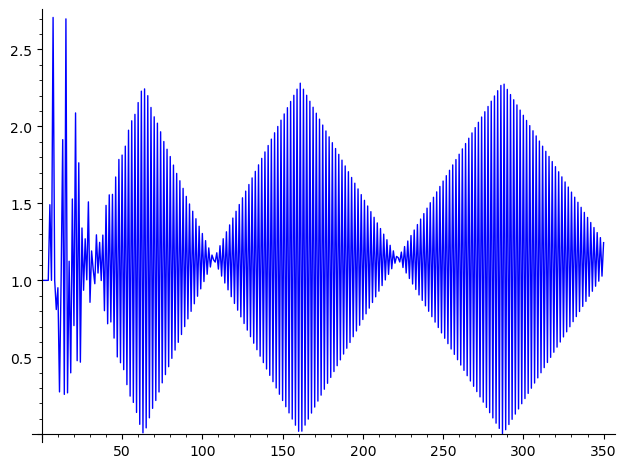

In [1]:
import pickle
from sage.all import sigma, nth_prime
import ast


with open('/Users/barrybrent/data2/run11mar26no102.txt', 'rb') as rfile:
    j_list = pickle.load(rfile)
    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    print(n)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        if minn>0:
            log_minn=log(minn)
            log_mins_list.append((n,log_minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run4april26no1.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run4april26no2.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run4april26no3.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped


Data range: n = 1 to 350
Number of data points: 350
Min modulus range: 0.004259 to 2.708074

Stage A: degree-2 polynomial detrend
  lag-1 autocorrelation of residuals: -0.9647
  ACF crosses zero within 116 lags: True
  --> Residual is oscillatory or low-autocorrelation. Polynomial detrend is sufficient.

Final detrending method: Polynomial (degree 2)
  Detrended data std dev: 0.6597

Envelope normalization: APPLIED
  Envelope dynamic range (p90/p10): 7.19
  Envelope smoothing window: 35
  Normalized data std dev: 1.0130

AR(1) lag-1 autocorrelation (rho): -0.9307
Frequency bins tested: 172
Bonferroni-corrected per-bin alpha: 95% -> 0.000291,  99% -> 0.000058

SIGNIFICANT FFT PEAKS  (period <= N/3 = 117, Bonferroni-corrected)
  No FFT peaks exceed the Bonferroni-corrected significance threshold.

MULTI-SCALE PERIOD DETECTION
  Period       Scale           ACF strength    Role                
  ------------------------------------------------------------
       2.0    raw                

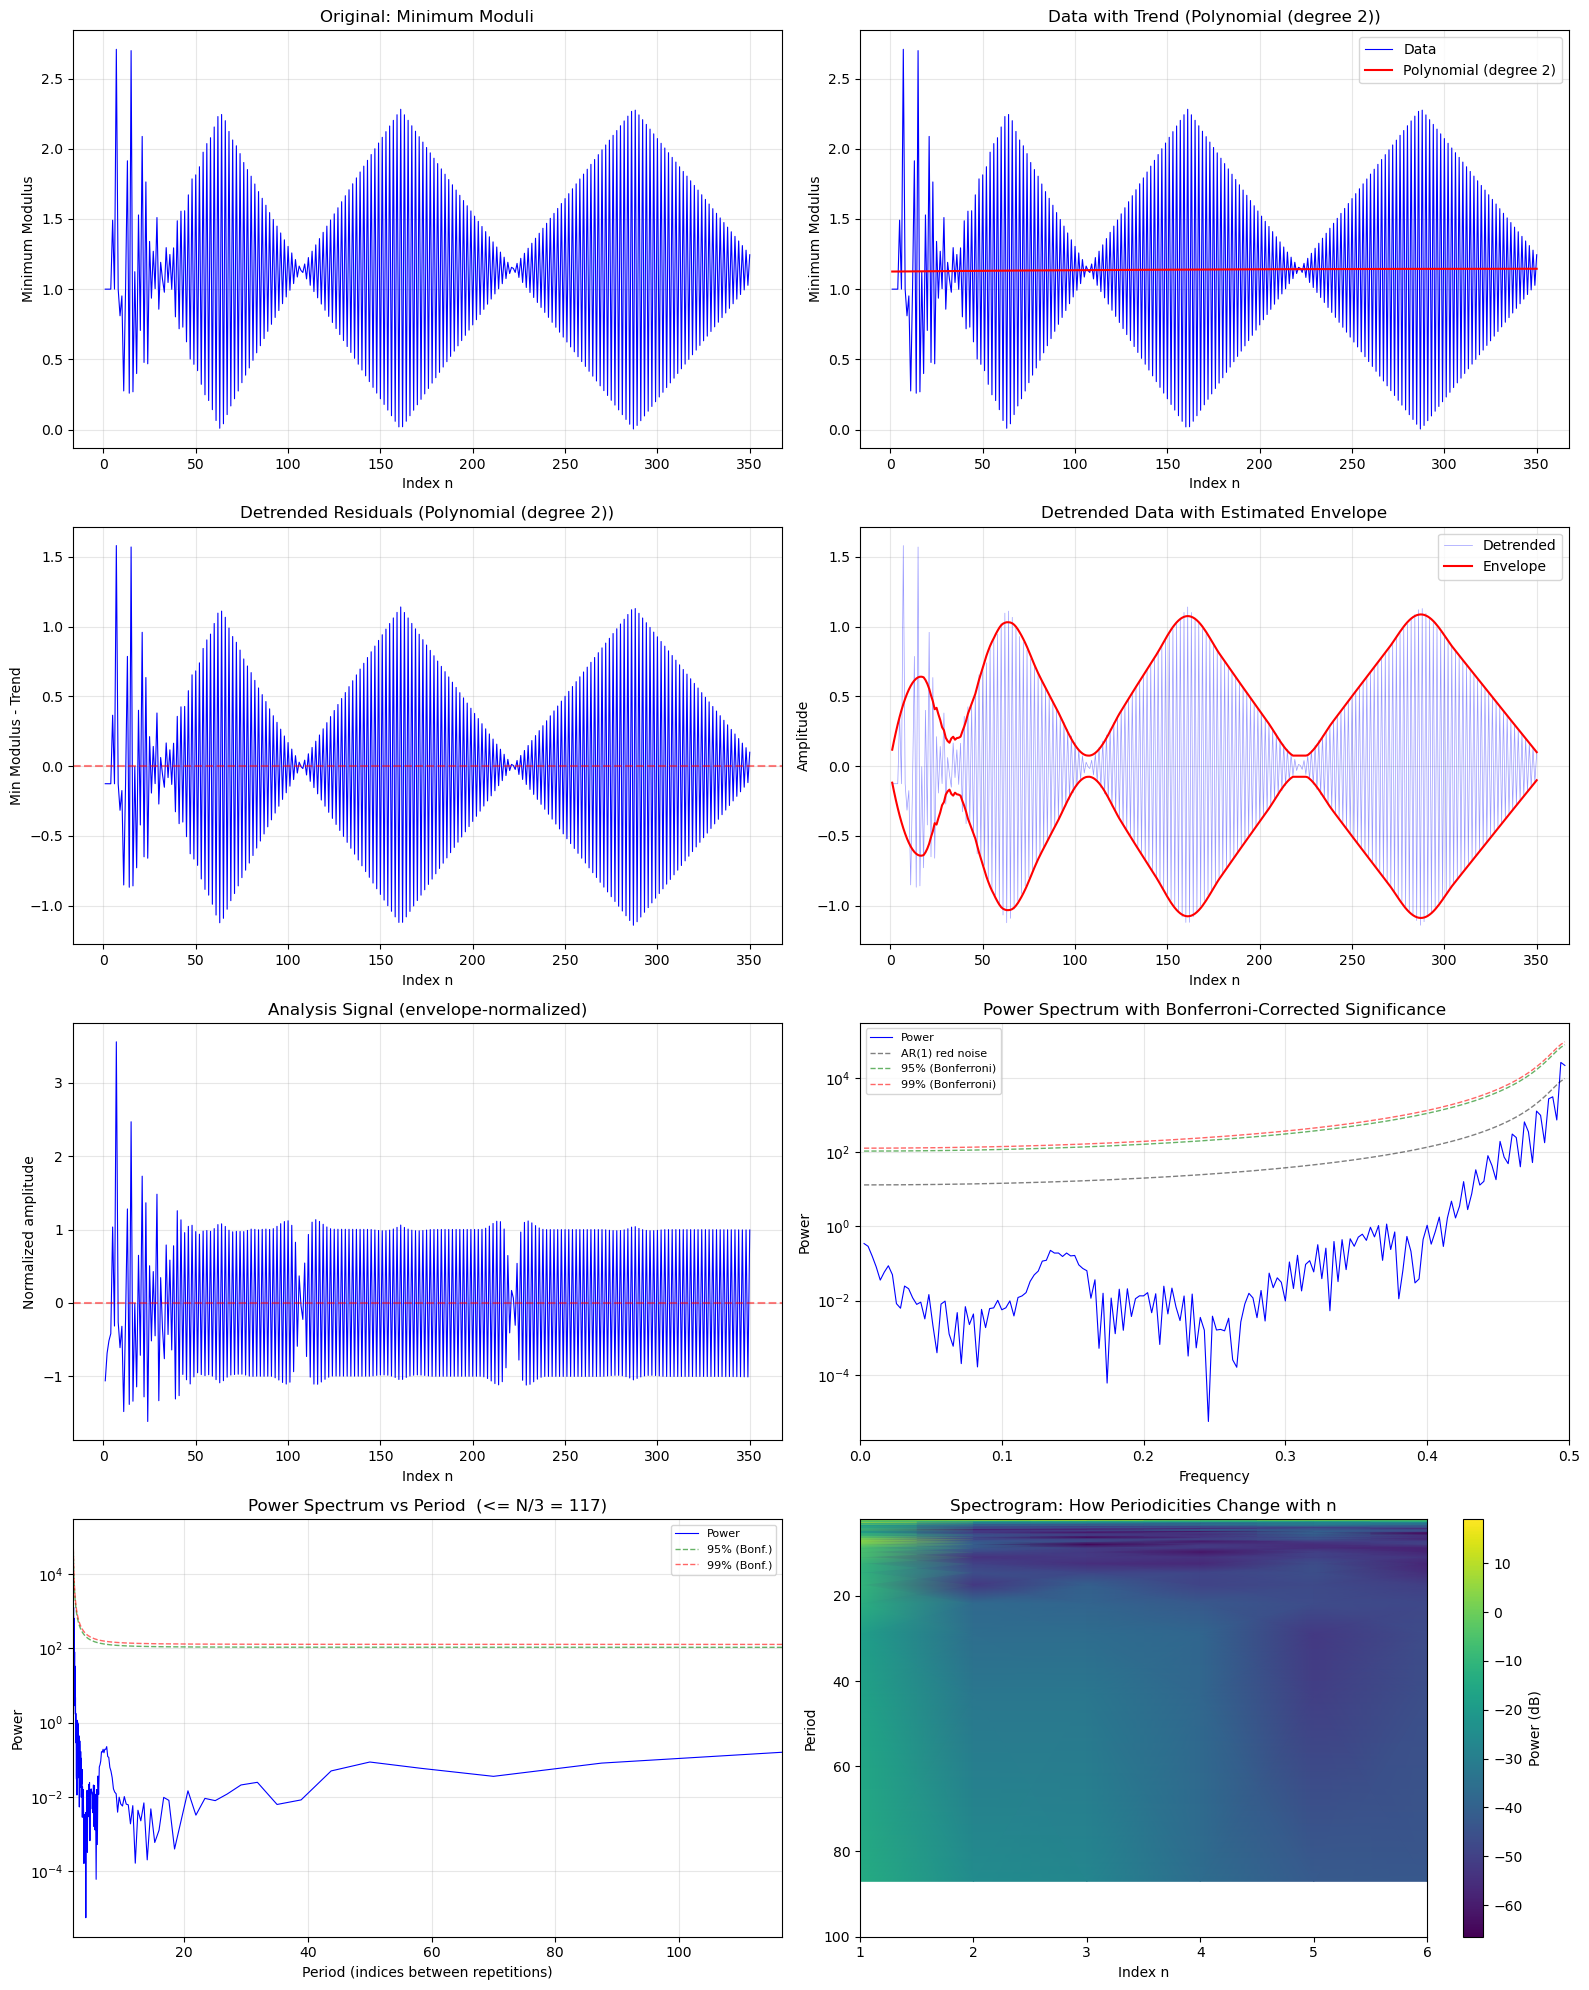


Analysis complete.


In [1]:
import pickle
with open('/Users/barrybrent/data2/run4april26no3.txt', 'rb') as rfile:
    mins_list = pickle.load(rfile)

# REVISED FOURIER ANALYSIS OF MINIMUM MODULI  (v9.3)
#
# NEW IN v9.3: ENVELOPE NORMALIZATION
#
# v8 had a blind spot for amplitude-modulated periodicity ‚Äî oscillations
# whose envelope decays or grows (e.g., minimum moduli of Chebyshev
# polynomial roots, which oscillate with period 2 but decay as ~1/n).
# Both the ACF and the AR(1) significance test assume roughly stationary
# amplitude.  When amplitude varies strongly:
#   - The ACF is dominated by the high-amplitude portion, producing weak
#     overall correlation.
#   - A negative AR(1) rho models the alternation as noise, raising the
#     significance threshold at high frequencies.
#
# Fix: after detrending, estimate the local amplitude envelope and divide
# it out, producing a signal with approximately constant amplitude.  All
# subsequent analysis (FFT, significance test, multi-scale ACF) operates
# on this normalized signal.
#
# It expects mins_list to already be defined.

import numpy as np
from scipy import signal, stats
import matplotlib.pyplot as plt

# ==============================================================================
# 1. PREPARE THE DATA
# ==============================================================================
indices   = np.array([float(pair[0]) for pair in mins_list], dtype=np.float64)
minmoduli = np.array([float(pair[1]) for pair in mins_list], dtype=np.float64)
N = len(indices)

print(f"Data range: n = {int(indices[0])} to {int(indices[-1])}")
print(f"Number of data points: {N}")
print(f"Min modulus range: {minmoduli.min():.6f} to {minmoduli.max():.6f}")

# ==============================================================================
# 2. ADAPTIVE DETRENDING  (safe for both trended and periodic data)
# ==============================================================================
max_credible_period = N / 3.0

# --- Stage A: low-order polynomial (captures broad drift only) ---
poly_deg = 2
poly_coeffs = np.polyfit(indices, minmoduli, deg=poly_deg)
poly_trend = np.polyval(poly_coeffs, indices)
resid_poly = minmoduli - poly_trend

# Measure whether the residual looks "trend-like" or "oscillation-like"
acf_lags = min(50, N // 4)
acf = np.correlate(resid_poly - resid_poly.mean(), resid_poly - resid_poly.mean(), 'full')
acf = acf[N-1:]  # positive lags only
acf = acf / acf[0]  # normalize

check_range = min(int(max_credible_period), len(acf))
acf_crosses_zero = np.any(acf[1:check_range] < 0)
r1_poly = np.corrcoef(resid_poly[:-1], resid_poly[1:])[0, 1]

print(f"\nStage A: degree-{poly_deg} polynomial detrend")
print(f"  lag-1 autocorrelation of residuals: {r1_poly:.4f}")
print(f"  ACF crosses zero within {check_range} lags: {acf_crosses_zero}")

TREND_THRESHOLD = 0.85

if not acf_crosses_zero and abs(r1_poly) > TREND_THRESHOLD:
    # --- Stage B: local smoother needed, but window capped ---
    print(f"  --> Residual is trend-like (r1={r1_poly:.4f}, no zero-crossing).")
    print(f"      Escalating to Savitzky-Golay, window capped at {int(max_credible_period)}.")

    sg_poly_order = 3
    max_sg_win = int(max_credible_period)
    if max_sg_win % 2 == 0:
        max_sg_win -= 1
    max_sg_win = max(max_sg_win, sg_poly_order + 2)

    candidate_windows = [w for w in range(21, max_sg_win + 1, 10) if w % 2 == 1]
    if not candidate_windows:
        candidate_windows = [max_sg_win]

    best_win, best_score = candidate_windows[0], np.inf
    for win in candidate_windows:
        trend = signal.savgol_filter(minmoduli, window_length=win, polyorder=sg_poly_order)
        resid = minmoduli - trend
        r1 = np.abs(np.corrcoef(resid[:-1], resid[1:])[0, 1])
        if r1 < best_score:
            best_score = r1
            best_win = win

    smooth_trend = signal.savgol_filter(minmoduli, window_length=best_win,
                                        polyorder=sg_poly_order)
    detrended = minmoduli - smooth_trend
    detrend_label = f"Savitzky-Golay (win={best_win}, order={sg_poly_order})"
    print(f"      Selected window: {best_win}")
    print(f"      lag-1 autocorrelation of residuals: {best_score:.4f}")
else:
    smooth_trend = poly_trend
    detrended = resid_poly
    detrend_label = f"Polynomial (degree {poly_deg})"
    print(f"  --> Residual is oscillatory or low-autocorrelation. "
          f"Polynomial detrend is sufficient.")

print(f"\nFinal detrending method: {detrend_label}")
print(f"  Detrended data std dev: {np.std(detrended):.4f}")

# ==============================================================================
# 2b. ENVELOPE NORMALIZATION  (new in v9)
# ==============================================================================
# Estimate the local amplitude envelope of the detrended signal.  If the
# envelope varies by more than a factor of 3 between its 10th and 90th
# percentiles, normalize by it so that the oscillation has roughly constant
# amplitude.  This makes the ACF and significance tests valid for
# amplitude-modulated periodic signals.

abs_detrended = np.abs(detrended)

# Smooth the absolute values to get an envelope estimate.
# Window width: use ~10% of N, at least 5, at most N//3, and must be odd.
env_win = max(5, min(N // 10, N // 3))
if env_win % 2 == 0:
    env_win += 1
envelope = signal.savgol_filter(abs_detrended, window_length=env_win,
                                polyorder=2)

# Floor the envelope to avoid division by near-zero
env_floor = np.percentile(abs_detrended[abs_detrended > 0], 5) if np.any(abs_detrended > 0) else 1.0
envelope = np.maximum(envelope, env_floor)

# Decide whether normalization is needed: check the dynamic range
env_p10 = np.percentile(envelope, 10)
env_p90 = np.percentile(envelope, 90)
envelope_ratio = env_p90 / env_p10 if env_p10 > 0 else 1.0

ENVELOPE_THRESHOLD = 3.0  # normalize if 90th/10th percentile ratio exceeds this

if envelope_ratio > ENVELOPE_THRESHOLD:
    normalized = detrended / envelope
    envelope_applied = True
    print(f"\nEnvelope normalization: APPLIED")
    print(f"  Envelope dynamic range (p90/p10): {envelope_ratio:.2f}")
    print(f"  Envelope smoothing window: {env_win}")
    print(f"  Normalized data std dev: {np.std(normalized):.4f}")
else:
    normalized = detrended
    envelope_applied = False
    print(f"\nEnvelope normalization: not needed")
    print(f"  Envelope dynamic range (p90/p10): {envelope_ratio:.2f}")

# Use the normalized signal for all subsequent analysis
analysis_signal = normalized

# ==============================================================================
# 3. WINDOWED FFT
# ==============================================================================
window = np.hanning(N)
windowed = analysis_signal * window
window_power_correction = N / np.sum(window**2)

fft_result     = np.fft.fft(windowed)
fft_freqs      = np.fft.fftfreq(N, d=1.0)
power_spectrum = np.abs(fft_result)**2 * window_power_correction

pos = fft_freqs > 0
frequencies = fft_freqs[pos]
power       = power_spectrum[pos]
periods     = 1.0 / frequencies

# ==============================================================================
# 4. AR(1) RED-NOISE SIGNIFICANCE WITH BONFERRONI CORRECTION
# ==============================================================================
rho = np.corrcoef(analysis_signal[:-1], analysis_signal[1:])[0, 1]
variance = np.var(analysis_signal)

# Theoretical AR(1) power spectrum (Gilman et al. 1963)
ar1_power = (variance * (1 - rho**2)) / (
    1 - 2 * rho * np.cos(2 * np.pi * frequencies) + rho**2
)
ar1_power *= np.mean(power) / np.mean(ar1_power)

# Number of independent frequency bins we're testing
credible_mask = periods <= max_credible_period
n_tests = int(np.sum(credible_mask))

# Bonferroni-corrected chi-squared thresholds
alpha_95_corrected = 1.0 - (0.05 / n_tests)
alpha_99_corrected = 1.0 - (0.01 / n_tests)

chi2_95 = stats.chi2.ppf(alpha_95_corrected, df=2) / 2.0
chi2_99 = stats.chi2.ppf(alpha_99_corrected, df=2) / 2.0
conf_95 = ar1_power * chi2_95
conf_99 = ar1_power * chi2_99

print(f"\nAR(1) lag-1 autocorrelation (rho): {rho:.4f}")
print(f"Frequency bins tested: {n_tests}")
print(f"Bonferroni-corrected per-bin alpha: "
      f"95% -> {0.05/n_tests:.6f},  99% -> {0.01/n_tests:.6f}")

# ==============================================================================
# 5. IDENTIFY SIGNIFICANT PEAKS  (FFT)
# ==============================================================================
peak_idx = signal.find_peaks(power, height=0)[0]
significant_peaks = []
for pi in peak_idx:
    if not credible_mask[pi]:
        continue
    if power[pi] > conf_99[pi]:
        significant_peaks.append((pi, '99%'))
    elif power[pi] > conf_95[pi]:
        significant_peaks.append((pi, '95%'))

significant_peaks.sort(key=lambda x: power[x[0]], reverse=True)

# ==============================================================================
# 5b. MULTI-SCALE FUNDAMENTAL PERIOD DETECTION
# ==============================================================================
# Waveforms can have structure at multiple scales: e.g. a sawtooth with
# period ~60 is built from small teeth with period ~3.  The FFT, naive ACF,
# and time-domain peak-finding all latch onto the finest scale because it
# has the sharpest features.
#
# Strategy: detect periodicity at MULTIPLE SCALES by progressively smoothing
# the analysis signal and re-measuring.  At each scale, compute the ACF
# and find its first peak above a quality threshold.  Collect all detected
# periods across scales and report them hierarchically.
#
# The fundamental is identified as the shortest detected period whose
# integer multiples account for most of the longer detected periods.

detected_periods = []  # list of (period, scale_label, acf_strength)

# Scales to try: raw, then moving-average windows of increasing width
smooth_widths = [1]  # 1 = no smoothing (raw)
w = 3
while w < max_credible_period / 2:
    smooth_widths.append(w)
    w = max(w + 2, int(w * 1.5))
    if w % 2 == 0:
        w += 1

for sw in smooth_widths:
    if sw == 1:
        smoothed = analysis_signal.copy()
        scale_label = "raw"
    else:
        # Moving average
        kernel = np.ones(sw) / sw
        smoothed = np.convolve(analysis_signal, kernel, mode='same')
        scale_label = f"MA({sw})"

    # Compute ACF of smoothed signal
    sm_centered = smoothed - smoothed.mean()
    acf_sm = np.correlate(sm_centered, sm_centered, 'full')
    acf_sm = acf_sm[N-1:]
    if acf_sm[0] > 0:
        acf_sm = acf_sm / acf_sm[0]
    else:
        continue

    # Find first ACF peak above zero with lag >= search_start.
    # Include one extra lag before search_start in the slice so that
    # find_peaks can detect a peak at the boundary (lag = search_start).
    search_start = max(2, sw + 1) if sw > 1 else 2
    search_end = min(int(max_credible_period), len(acf_sm) - 1)
    if search_start >= search_end:
        continue

    slice_begin = max(0, search_start - 1)  # one extra lag for left neighbor
    acf_slice = acf_sm[slice_begin:search_end+1]
    peaks_in_slice, props = signal.find_peaks(acf_slice, height=0.1)

    # Also check the boundary explicitly: if lag = search_start is a local
    # max relative to its neighbors AND exceeds the height threshold, but
    # find_peaks missed it (e.g. because slice_begin == search_start and
    # it's at index 0), add it manually.
    boundary_offset = search_start - slice_begin
    if (boundary_offset not in peaks_in_slice and
            search_start < len(acf_sm) - 1 and search_start > 0):
        val = acf_sm[search_start]
        left = acf_sm[search_start - 1]
        right = acf_sm[search_start + 1]
        if val > left and val > right and val > 0.1:
            peaks_in_slice = np.concatenate(([boundary_offset], peaks_in_slice))

    if len(peaks_in_slice) > 0:
        # Convert slice indices back to true lags
        true_lags = peaks_in_slice + slice_begin
        # Keep only lags >= search_start
        true_lags = true_lags[true_lags >= search_start]

        if len(true_lags) > 0:
            lag = int(true_lags[0])  # first qualifying peak
            strength = acf_sm[lag]

            # Check this isn't a duplicate of an already-detected period
            is_new = True
            for (prev_p, _, _) in detected_periods:
                if abs(lag - prev_p) / max(lag, prev_p) < 0.15:
                    is_new = False
                    break
            if is_new:
                detected_periods.append((float(lag), scale_label, float(strength)))

# Sort by period length (shortest first for fundamental detection)
detected_periods.sort(key=lambda x: x[0])

# Identify the fundamental: the shortest detected period whose integer
# multiples account for most of the longer detected periods.
# (For a period-2 signal, ACF peaks at lags 2, 4, 6, 8, ... are all
# integer multiples of 2.  The fundamental is 2, not 8.)
fund_period = None
fund_method = None
fund_strength = None
sub_periods = []

if detected_periods:
    best_fund_idx = 0
    best_explained = 0

    for i, (cand_p, cand_label, cand_str) in enumerate(detected_periods):
        if cand_p < 2:
            continue
        n_explained = 0
        for j, (other_p, _, _) in enumerate(detected_periods):
            if j == i:
                n_explained += 1
                continue
            ratio = other_p / cand_p
            nearest = round(ratio)
            if nearest >= 1 and abs(ratio - nearest) / max(nearest, 1) < 0.15:
                n_explained += 1
        if n_explained > best_explained or (
                n_explained == best_explained and cand_str > detected_periods[best_fund_idx][2]):
            best_explained = n_explained
            best_fund_idx = i

    fund_period = detected_periods[best_fund_idx][0]
    fund_method = f"multi-scale ACF ({detected_periods[best_fund_idx][1]})"
    fund_strength = detected_periods[best_fund_idx][2]
    sub_periods = [dp for k, dp in enumerate(detected_periods) if k != best_fund_idx]

    # Re-sort sub_periods longest first for display
    sub_periods.sort(key=lambda x: x[0], reverse=True)

# ==============================================================================
# 5c. REPORTING
# ==============================================================================
print("\n" + "="*75)
print(f"SIGNIFICANT FFT PEAKS  (period <= N/3 = {max_credible_period:.0f}, "
      f"Bonferroni-corrected)")
print("="*75)
if significant_peaks:
    print(f"{'Rank':<6} {'Period':<12} {'Frequency':<12} {'Power':<15} {'Signif.':<10}")
    print("-"*75)
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        print(f"{rank:<6} {periods[pi]:>10.2f} {frequencies[pi]:>10.6f} "
              f"{power[pi]:>12.2e}   {level}")
else:
    print("  No FFT peaks exceed the Bonferroni-corrected significance threshold.")

# --- Multi-scale period detection ---
print("\n" + "="*75)
print("MULTI-SCALE PERIOD DETECTION")
print("="*75)
if fund_period is not None:
    print(f"  {'Period':<12} {'Scale':<15} {'ACF strength':<15} {'Role':<20}")
    print(f"  {'-'*60}")
    print(f"  {fund_period:>8.1f}    {detected_periods[best_fund_idx][1]:<15} "
          f"{fund_strength:>10.4f}      FUNDAMENTAL")
    for (p, label, strength) in sub_periods:
        print(f"  {p:>8.1f}    {label:<15} {strength:>10.4f}      integer multiple")
elif detected_periods:
    print(f"  {'Period':<12} {'Scale':<15} {'ACF strength':<15}")
    print(f"  {'-'*45}")
    for (p, label, strength) in detected_periods:
        print(f"  {p:>8.1f}    {label:<15} {strength:>10.4f}")
else:
    print("  No periodicity detected at any scale.")

# --- Harmonic analysis ---
if fund_period is not None and significant_peaks:
    print(f"\n  Harmonic analysis (FFT peaks as multiples of fundamental "
          f"= {fund_period:.1f}):")
    print(f"  {'Rank':<6} {'FFT Period':<12} {'T_fund / T_peak':<18} "
          f"{'Nearest int':<12} {'Harmonic?':<10}")
    print(f"  {'-'*70}")
    for rank, (pi, level) in enumerate(significant_peaks[:15], 1):
        ratio = fund_period / periods[pi]
        nearest = round(ratio)
        is_harmonic = (nearest >= 1 and
                       abs(ratio - nearest) < 0.15 * max(nearest, 1))
        tag = f"~{nearest}x" if is_harmonic else "independent"
        print(f"  {rank:<6} {periods[pi]:>10.2f} {ratio:>14.4f}     "
              f"{nearest:>6}     {tag}")

# --- Summary ---
print("\n" + "="*75)
print("SUMMARY")
print("="*75)

# Determine the overall verdict by combining FFT and ACF evidence.
has_fft_evidence = len(significant_peaks) > 0
has_acf_evidence = fund_period is not None and fund_strength > 0.5
has_weak_acf     = fund_period is not None and 0.2 < fund_strength <= 0.5
has_marginal_acf = fund_period is not None and fund_strength <= 0.2

if has_acf_evidence:
    # --- Positive verdict: strong ACF evidence (with or without FFT) ---
    print(f"  PERIODIC.  Fundamental period: {fund_period:.1f}")
    print(f"    Detection method: {fund_method}")
    print(f"    ACF strength: {fund_strength:.4f}")
    if envelope_applied:
        print(f"    Envelope normalization was applied (dynamic range "
              f"{envelope_ratio:.1f}x).")
    if sub_periods:
        sub_str = ", ".join(f"{p:.1f}" for p, _, _ in sub_periods)
        print(f"    Integer multiples also detected at period(s): {sub_str}")
    # Explain FFT vs ACF agreement or disagreement
    if has_fft_evidence:
        print(f"    Evidence: both FFT and ACF confirm periodicity.")
    else:
        if fund_period <= 2.5:
            print(f"    Note: the FFT did not confirm this period.  At period ~2")
            print(f"    (the Nyquist limit), the Hann window strongly attenuates")
            print(f"    the signal.  The ACF is not affected by this limitation.")
        else:
            print(f"    Note: the FFT did not confirm this period (the peak did")
            print(f"    not exceed the Bonferroni-corrected threshold), but the")
            print(f"    ACF strength of {fund_strength:.4f} is strong independent")
            print(f"    evidence of periodicity.")
    # Report FFT harmonic structure if available
    if has_fft_evidence and fund_period is not None:
        dominant_fft_period = periods[significant_peaks[0][0]]
        ratio_to_fund = fund_period / dominant_fft_period
        nearest = round(ratio_to_fund)
        if nearest > 1 and abs(ratio_to_fund - nearest) < 0.15 * nearest:
            print(f"    Dominant FFT peak (period {dominant_fft_period:.2f}) is the "
                  f"~{nearest}x harmonic of the fundamental.")
            print(f"    The waveform is non-sinusoidal.")
        elif nearest <= 1:
            print(f"    Dominant FFT peak (period {dominant_fft_period:.2f}) matches "
                  f"the fundamental.")

elif has_fft_evidence:
    # --- FFT finds peaks but ACF is weak or absent ---
    print(f"  PERIODIC (FFT only).")
    dominant_fft_period = periods[significant_peaks[0][0]]
    print(f"    Dominant FFT period: {dominant_fft_period:.2f}")
    if fund_period is not None:
        print(f"    Multi-scale ACF suggests fundamental: {fund_period:.1f} "
              f"(strength {fund_strength:.4f})")
    print(f"    Note: FFT detects significant peaks, but the multi-scale")
    print(f"    ACF did not find a strong fundamental.  Interpret with caution.")

elif has_weak_acf:
    print(f"  POSSIBLY PERIODIC.  Candidate period: {fund_period:.1f}")
    print(f"    ACF strength {fund_strength:.4f} is moderate (threshold: 0.5).")
    print(f"    The FFT does not confirm.  Interpret with caution.")
    if envelope_applied:
        print(f"    Envelope normalization was applied (dynamic range "
              f"{envelope_ratio:.1f}x).")

elif has_marginal_acf:
    print("  NOT PERIODIC.  Weak ACF signal (strength < 0.2) does not")
    print("  constitute evidence of periodicity.")

else:
    print("  NOT PERIODIC.  Neither the FFT nor the ACF finds evidence")
    print("  of oscillatory behavior.")

# ==============================================================================
# 6. VISUALIZATIONS
# ==============================================================================
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# 6.1  Original data
axes[0, 0].plot(indices, minmoduli, 'b-', linewidth=0.8)
axes[0, 0].set_xlabel('Index n')
axes[0, 0].set_ylabel('Minimum Modulus')
axes[0, 0].set_title('Original: Minimum Moduli')
axes[0, 0].grid(True, alpha=0.3)

# 6.2  Trend overlay
axes[0, 1].plot(indices, minmoduli, 'b-', linewidth=0.8, label='Data')
axes[0, 1].plot(indices, smooth_trend, 'r-', linewidth=1.5,
                label=detrend_label)
axes[0, 1].set_xlabel('Index n')
axes[0, 1].set_ylabel('Minimum Modulus')
axes[0, 1].set_title(f'Data with Trend ({detrend_label})')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 6.3  Detrended data (before envelope normalization)
axes[1, 0].plot(indices, detrended, 'b-', linewidth=0.8)
axes[1, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1, 0].set_xlabel('Index n')
axes[1, 0].set_ylabel('Min Modulus - Trend')
axes[1, 0].set_title(f'Detrended Residuals ({detrend_label})')
axes[1, 0].grid(True, alpha=0.3)

# 6.4  Envelope-normalized data (or detrended if no normalization)
if envelope_applied:
    axes[1, 1].plot(indices, detrended, 'b-', linewidth=0.5, alpha=0.4,
                    label='Detrended')
    axes[1, 1].plot(indices, envelope, 'r-', linewidth=1.5, label='Envelope')
    axes[1, 1].plot(indices, -envelope, 'r-', linewidth=1.5)
    axes[1, 1].set_xlabel('Index n')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].set_title('Detrended Data with Estimated Envelope')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].plot(indices, analysis_signal, 'b-', linewidth=0.8)
    axes[1, 1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
    axes[1, 1].set_xlabel('Index n')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].set_title('Analysis Signal (no envelope normalization needed)')
    axes[1, 1].grid(True, alpha=0.3)

# 6.5  Normalized signal (what the FFT and ACF actually see)
axes[2, 0].plot(indices, analysis_signal, 'b-', linewidth=0.8)
axes[2, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[2, 0].set_xlabel('Index n')
axes[2, 0].set_ylabel('Normalized amplitude')
title_suffix = " (envelope-normalized)" if envelope_applied else ""
axes[2, 0].set_title(f'Analysis Signal{title_suffix}')
axes[2, 0].grid(True, alpha=0.3)

# 6.6  Power spectrum with corrected confidence bands
axes[2, 1].semilogy(frequencies, power, 'b-', linewidth=0.8, label='Power')
axes[2, 1].semilogy(frequencies, ar1_power, 'k--', linewidth=1,
                    alpha=0.5, label='AR(1) red noise')
axes[2, 1].semilogy(frequencies, conf_95, 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonferroni)')
axes[2, 1].semilogy(frequencies, conf_99, 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonferroni)')
for pi, level in significant_peaks:
    color = 'red' if level == '99%' else 'orange'
    axes[2, 1].semilogy(frequencies[pi], power[pi], 'o',
                        color=color, markersize=8)
axes[2, 1].set_xlabel('Frequency')
axes[2, 1].set_ylabel('Power')
axes[2, 1].set_title('Power Spectrum with Bonferroni-Corrected Significance')
axes[2, 1].legend(fontsize=8)
axes[2, 1].grid(True, alpha=0.3)
axes[2, 1].set_xlim(0, 0.5)

# 6.7  Power spectrum vs period
pmask = (periods <= max_credible_period) & (periods >= 2)
axes[3, 0].semilogy(periods[pmask], power[pmask], 'b-', linewidth=0.8,
                    label='Power')
axes[3, 0].semilogy(periods[pmask], conf_95[pmask], 'g--', linewidth=1,
                    alpha=0.6, label='95% (Bonf.)')
axes[3, 0].semilogy(periods[pmask], conf_99[pmask], 'r--', linewidth=1,
                    alpha=0.6, label='99% (Bonf.)')
for pi, level in significant_peaks:
    if periods[pi] <= max_credible_period:
        color = 'red' if level == '99%' else 'orange'
        axes[3, 0].semilogy(periods[pi], power[pi], 'o',
                            color=color, markersize=8)
axes[3, 0].set_xlabel('Period (indices between repetitions)')
axes[3, 0].set_ylabel('Power')
axes[3, 0].set_title(f'Power Spectrum vs Period  (<= N/3 = {max_credible_period:.0f})')
axes[3, 0].legend(fontsize=8)
axes[3, 0].grid(True, alpha=0.3)
axes[3, 0].set_xlim(2, max_credible_period)

# 6.8  Spectrogram
window_size = min(128, N // 4)
fspec, tspec, Sxx = signal.spectrogram(analysis_signal, fs=1.0,
                                       nperseg=window_size,
                                       noverlap=window_size // 2)
periodspec = 1.0 / (fspec[1:] + 1e-10)
Sxx = Sxx[1:, :]
im = axes[3, 1].pcolormesh(indices[:len(tspec)], periodspec,
                           10 * np.log10(Sxx + 1e-10),
                           shading='gouraud', cmap='viridis')
axes[3, 1].set_xlabel('Index n')
axes[3, 1].set_ylabel('Period')
axes[3, 1].set_title('Spectrogram: How Periodicities Change with n')
axes[3, 1].set_ylim(2, min(100, max_credible_period))
axes[3, 1].invert_yaxis()
plt.colorbar(im, ax=axes[3, 1], label='Power (dB)')

plt.tight_layout()
plt.show()

print("\n" + "="*75)
print("Analysis complete.")
print("="*75)
